# Libraries and loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import pickle

import os
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
Colors = sns.color_palette("colorblind", 16).as_hex()
import matplotlib.pyplot as plt
text_size=26
fig_size_x=24
fig_size_y=14
from scipy.interpolate import interp1d
import pandas as pd
import ast
import time
from collections import defaultdict
import math


def nested_dict(n, type):
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
    


In [4]:
do_the_analysis = False;


L= 1024.
sims= ["0.15ev", "0.3ev" , "0.6ev"];
specs = ["L_1024_Ngrid_512", "L_1024_Ngrid_1024"]
if do_the_analysis == True:

    for spec in specs:
        for sim in sims:
            df = pd.DataFrame()
            file_path = "./../old_Runs-Bulk-nu-cdm-halo/"+spec+"/"+sim
            for ngrid in np.arange(1,75,2):
                cdm_path =file_path+"/cdm/output/data_ngrid_"+str(ngrid)+"_sim_"+sim+"_"+spec+"_snap002_cdm.pickle"
                nu_path =file_path+"/nu/output/data_ngrid_"+str(ngrid)+"_sim_"+sim+"_"+spec+"_snap002_ncdm0.pickle"
                halo_all_path =file_path+"/halo/output/data_ngrid_"+str(ngrid)+"_sim_"+sim+"_"+spec+"_halos_out_2.pickle"
                halo_mass1_path =file_path+"/halo_mass_5e13/output/data_ngrid_"+str(ngrid)+"_sim_"+sim+"_"+spec+"_halos_out_2.pickle"
                halo_mass2_path =file_path+"/halo_mass_7e13/output/data_ngrid_"+str(ngrid)+"_sim_"+sim+"_"+spec+"_halos_out_2.pickle"
                
                if (not os.path.exists(cdm_path)):
                    print(cdm_path," doesn't exist/ cdm!")
                if (not os.path.exists(nu_path)):
                    print(nu_path,"doesn't exist/ nu!")
                if (not os.path.exists(halo_all_path)):
                    print(halo_all_path,"doesn't exist/ halo!")
                if (not os.path.exists(halo_mass1_path)):
                    print(halo_mass1_path,"doesn't exist/ halo!")
                if (not os.path.exists(halo_mass2_path)):
                    print(halo_mass2_path,"doesn't exist/ halo!")
                if (os.path.exists(cdm_path) and os.path.exists(nu_path) and os.path.exists(halo_all_path) and os.path.exists(halo_mass1_path) and os.path.exists(halo_mass2_path)):
                    print("Doing analysis for", ngrid, sim, spec)
                    cdm_bulk_all = np.load(cdm_path, allow_pickle=True)
                    nu_bulk_all = np.load(nu_path, allow_pickle=True)
                    halo_bulk_all = np.load(halo_all_path, allow_pickle=True)
                    halo_5e13_bulk_all = np.load(halo_mass1_path, allow_pickle=True)
                    halo_7e13_bulk_all = np.load(halo_mass2_path, allow_pickle=True)
                    ##########
                    corr_coeff = 0.;
                    corr_coeff_mass_5e13 = 0.
                    corr_coeff_mass_7e13=0.
                    #####
                    v_h_dot_v_nuc_print = 0.
                    v_h_mass_5e13_dot_v_nuc_print=0.
                    v_h_mass_7e13_dot_v_nuc_print=0.
                    ######
                    v_cnu_dot_v_cnu_print = 0.
                    v_c_dot_v_c_print = 0.
                    v_nu_dot_v_nu_print = 0.
                    v_h_dot_v_h_print = 0.
                    v_h_dot_v_h_m5e13_print=0
                    v_h_dot_v_h_m7e13_print=0
                    ########
                    for sub_box in np.arange(cdm_bulk_all.shape[0]):
                        #############
                        v_c_cell = cdm_bulk_all['bulk_vel'][sub_box];
                        v_nu_cell = nu_bulk_all['bulk_vel'][sub_box];
                        v_cnu_cell = v_c_cell - v_nu_cell;
                        #############
                        v_cnu_dot_v_cnu_print += np.dot(v_cnu_cell, v_cnu_cell)
                        v_c_dot_v_c_print += np.dot(v_c_cell, v_c_cell)
                        v_nu_dot_v_nu_print += np.dot(v_nu_cell, v_nu_cell)
                        #############
                        v_h_cell = halo_bulk_all['bulk_vel'][sub_box];
                        v_h_dot_v_nuc = np.dot(v_cnu_cell, v_h_cell) # v_h.(v_c - v_nu) all vectors!
                        v_h_dot_v_h = np.dot(v_h_cell, v_h_cell)
                        if v_h_dot_v_h != 0 and not math.isnan(v_h_dot_v_nuc/v_h_dot_v_h):
                            v_h_dot_v_h_print += v_h_dot_v_h
                            v_h_dot_v_nuc_print+=v_h_dot_v_nuc
                            corr_coeff += v_h_dot_v_nuc/v_h_dot_v_h;
                        ##############
                        v_h_cell = halo_5e13_bulk_all['bulk_vel'][sub_box];
                        v_h_dot_v_nuc = np.dot(v_cnu_cell, v_h_cell) # v_h.(v_c - v_nu) all vectors!
                        v_h_dot_v_h = np.dot(v_h_cell, v_h_cell)
                        if v_h_dot_v_h != 0 and not math.isnan(v_h_dot_v_nuc/v_h_dot_v_h):
                            v_h_dot_v_h_m5e13_print += v_h_dot_v_h
                            v_h_mass_5e13_dot_v_nuc_print+=v_h_dot_v_nuc
                            corr_coeff_mass_5e13 += v_h_dot_v_nuc / v_h_dot_v_h
                        ##############
                        v_h_cell = halo_7e13_bulk_all['bulk_vel'][sub_box];
                        v_h_dot_v_nuc = np.dot(v_cnu_cell, v_h_cell) # v_h.(v_c - v_nu) all vectors!
                        v_h_dot_v_h = np.dot(v_h_cell, v_h_cell)
                        if v_h_dot_v_h != 0 and not math.isnan(v_h_dot_v_nuc/v_h_dot_v_h):
                            v_h_dot_v_h_m7e13_print += v_h_dot_v_h
                            v_h_mass_7e13_dot_v_nuc_print+=v_h_dot_v_nuc
                            corr_coeff_mass_7e13 += v_h_dot_v_nuc / v_h_dot_v_h


                        # create a dictionary with the values
                    row_dict = {'sim': sim, 'n_grid': ngrid, 'dx': L/ngrid, 'v_cnu.v_h/v_h^2':corr_coeff/ngrid**3, 'v_cnu.v_h/v_h^2(M>5.e13)':corr_coeff_mass_5e13/ngrid**3,
                                'v_cnu.v_h/v_h^2(M>7.e13)':corr_coeff_mass_7e13/ngrid**3, 'v_cnu.v_cnu':v_cnu_dot_v_cnu_print/ngrid**3,
                                'v_c.v_c':v_c_dot_v_c_print/ngrid**3, 'v_nu.v_nu':v_nu_dot_v_nu_print/ngrid**3, 'v_h.v_h':v_h_dot_v_h_print/ngrid**3,
                               'v_h.v_h(M>5.e13)':v_h_dot_v_h_m5e13_print/ngrid**3, 'v_h.v_h(M>7.e13)':v_h_dot_v_h_m7e13_print/ngrid**3, 'v_h.v_nuc':v_h_dot_v_nuc_print/ngrid**3, 'v_h.v_nuc(M>5.e13)':v_h_mass_5e13_dot_v_nuc_print/ngrid**3,
                               'v_h.v_nuc(M>7.e13)':v_h_mass_7e13_dot_v_nuc_print/ngrid**3}
                # append the row to the dataframe
                    df = df.append(row_dict, ignore_index=True)


            df.to_csv('./bulk_velocity_analysis/bulk_vel_sim_'+sim+'_'+spec+'.csv', index=False);

            

Doing analysis for 1 0.15ev L_1024_Ngrid_512
Doing analysis for 3 0.15ev L_1024_Ngrid_512
Doing analysis for 5 0.15ev L_1024_Ngrid_512
Doing analysis for 7 0.15ev L_1024_Ngrid_512
Doing analysis for 9 0.15ev L_1024_Ngrid_512
Doing analysis for 11 0.15ev L_1024_Ngrid_512
Doing analysis for 13 0.15ev L_1024_Ngrid_512
Doing analysis for 15 0.15ev L_1024_Ngrid_512
Doing analysis for 17 0.15ev L_1024_Ngrid_512
Doing analysis for 19 0.15ev L_1024_Ngrid_512
Doing analysis for 21 0.15ev L_1024_Ngrid_512
Doing analysis for 23 0.15ev L_1024_Ngrid_512
Doing analysis for 25 0.15ev L_1024_Ngrid_512
Doing analysis for 27 0.15ev L_1024_Ngrid_512
Doing analysis for 29 0.15ev L_1024_Ngrid_512
Doing analysis for 31 0.15ev L_1024_Ngrid_512
Doing analysis for 33 0.15ev L_1024_Ngrid_512
Doing analysis for 35 0.15ev L_1024_Ngrid_512
Doing analysis for 37 0.15ev L_1024_Ngrid_512
Doing analysis for 39 0.15ev L_1024_Ngrid_512
Doing analysis for 41 0.15ev L_1024_Ngrid_512
Doing analysis for 43 0.15ev L_1024_Ngr

# Loading the files

In [120]:
data = nested_dict(5, float)  # Set the default value type as float

for spec in specs:
    for sim in sims:
        data[sim][spec]= pd.read_csv('./bulk_velocity_analysis/bulk_vel_sim_'+sim+'_'+spec+'.csv');

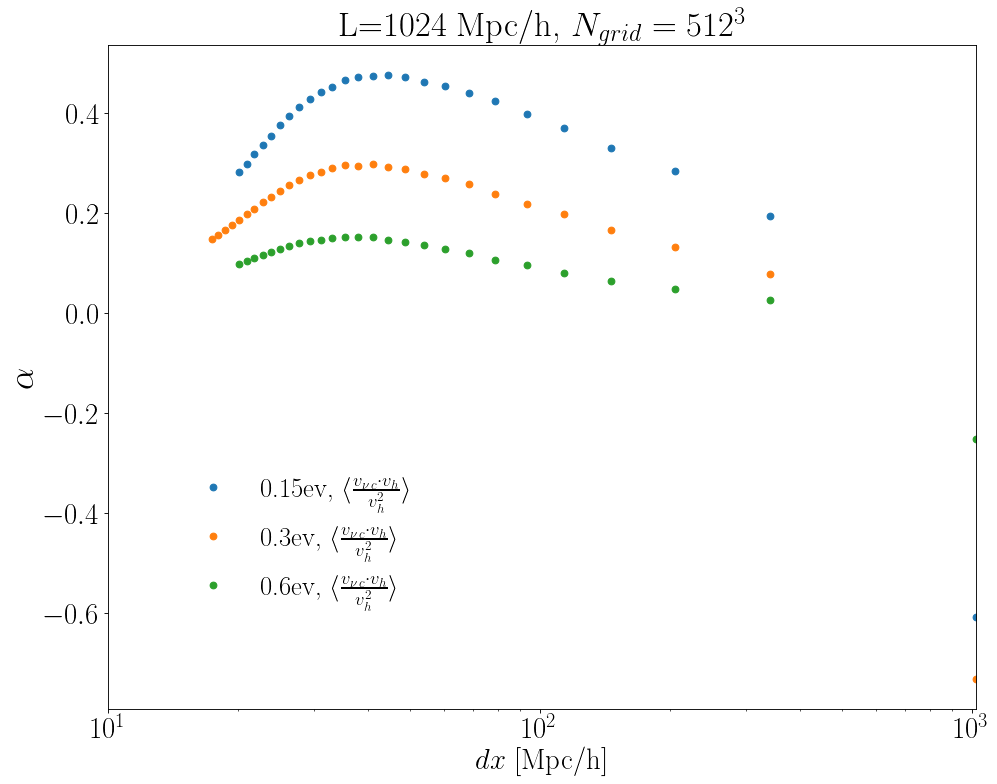

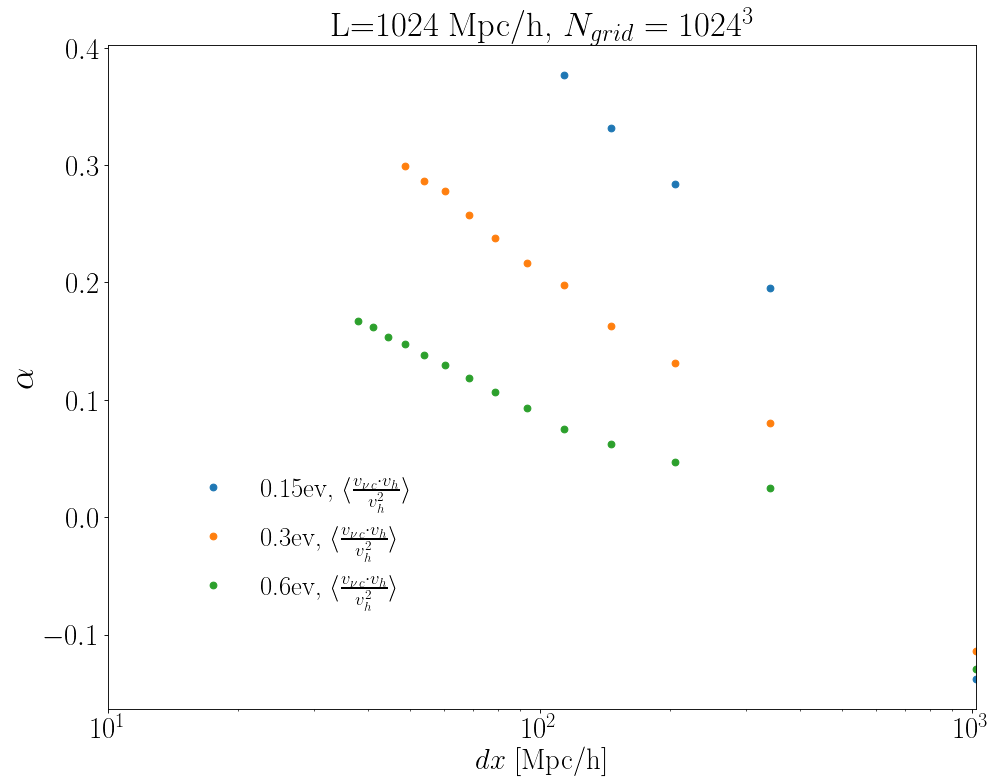

In [121]:
c = 26
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': c}
matplotlib.rc('font', **font)

for spec in specs:
    figure(figsize=(14, 11), dpi=80)
    if spec == "L_1024_Ngrid_512":
        title_name = r"L=1024 Mpc/h, $N_{grid}=512^3$"
    elif spec == "L_1024_Ngrid_1024":
        title_name = r"L=1024 Mpc/h, $N_{grid}=1024^3$"
    
    for sim in sims:
        ###FIG###
        dx = data[sim][spec]['dx']
        d1 = data[sim][spec]['v_cnu.v_h/v_h^2']
        d2 = data[sim][spec]['v_cnu.v_h/v_h^2(M>5.e13)']
        d3 = data[sim][spec]['v_cnu.v_h/v_h^2(M>7.e13)']

        plt.plot(dx, d1 ,"o", label =sim+r", $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro", label =r"$<v_{h}>$")

#             else:
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p) ,"bo")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro")

        plt.xlim(10,1024)
        plt.title(title_name)
        # plt.ylim(1,1.e5)
        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r'$\alpha$',fontsize=32)
        plt.xscale('log')
        plt.legend(fontsize=24,bbox_to_anchor=[0.22,0.25],loc="center",frameon=False)# plt.yscale('symlog')

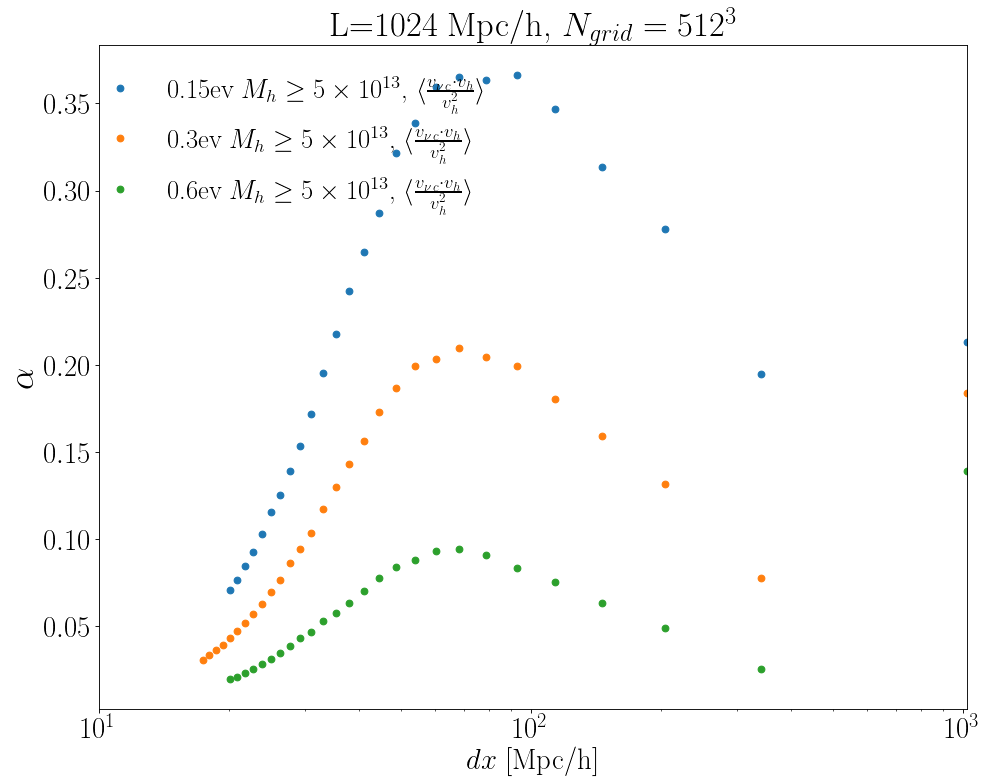

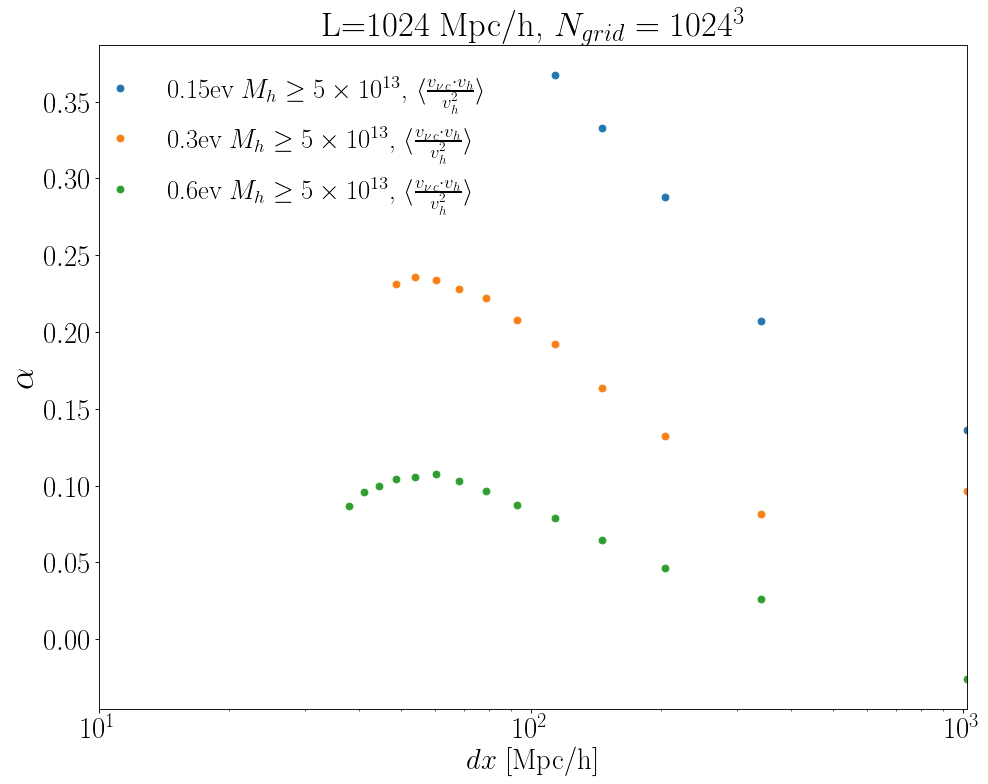

In [122]:
c = 26
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': c}
matplotlib.rc('font', **font)

for spec in specs:
    figure(figsize=(14, 11), dpi=80)
    if spec == "L_1024_Ngrid_512":
        title_name = r"L=1024 Mpc/h, $N_{grid}=512^3$"
    elif spec == "L_1024_Ngrid_1024":
        title_name = r"L=1024 Mpc/h, $N_{grid}=1024^3$"
    
    for sim in sims:
        ###FIG###
        dx = data[sim][spec]['dx']
        d1 = data[sim][spec]['v_cnu.v_h/v_h^2']
        d2 = data[sim][spec]['v_cnu.v_h/v_h^2(M>5.e13)']
        d3 = data[sim][spec]['v_cnu.v_h/v_h^2(M>7.e13)']

        plt.plot(dx, d2 ,"o", label =sim+r" $M_h \ge 5 \times 10^{13}$, $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro", label =r"$<v_{h}>$")

#             else:
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p) ,"bo")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro")

        plt.xlim(10,1024)
        plt.title(title_name)
        # plt.ylim(1,1.e5)
        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r'$\alpha$',fontsize=32)
        plt.xscale('log')
        plt.legend(fontsize=24,bbox_to_anchor=[0.22,0.85],loc="center",frameon=False)# plt.yscale('symlog')

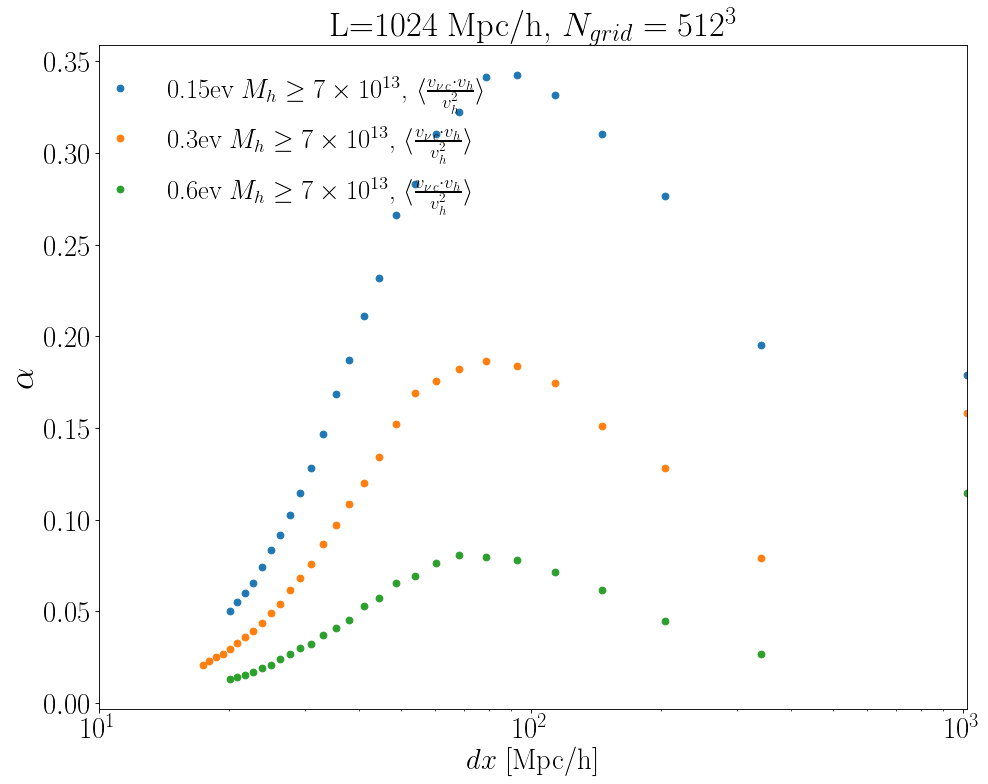

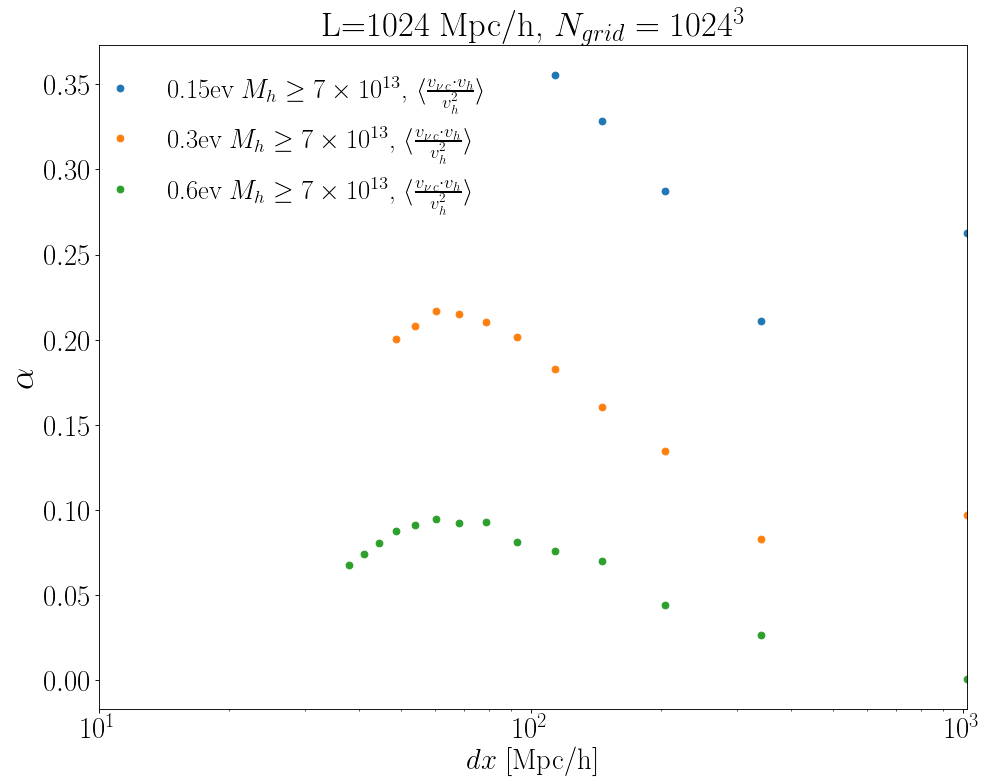

In [123]:
c = 26
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': c}
matplotlib.rc('font', **font)

for spec in specs:
    figure(figsize=(14, 11), dpi=80)
    if spec == "L_1024_Ngrid_512":
        title_name = r"L=1024 Mpc/h, $N_{grid}=512^3$"
    elif spec == "L_1024_Ngrid_1024":
        title_name = r"L=1024 Mpc/h, $N_{grid}=1024^3$"
    
    for sim in sims:
        ###FIG###
        dx = data[sim][spec]['dx']
        d1 = data[sim][spec]['v_cnu.v_h/v_h^2']
        d2 = data[sim][spec]['v_cnu.v_h/v_h^2(M>5.e13)']
        d3 = data[sim][spec]['v_cnu.v_h/v_h^2(M>7.e13)']

        plt.plot(dx, d3 ,"o", label =sim+r" $M_h \ge 7 \times 10^{13}$, $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro", label =r"$<v_{h}>$")

#             else:
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p) ,"bo")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro")

        plt.xlim(10,1024)
        plt.title(title_name)
        # plt.ylim(1,1.e5)
        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r'$\alpha$',fontsize=32)
        plt.xscale('log')
        plt.legend(fontsize=24,bbox_to_anchor=[0.22,0.85],loc="center",frameon=False)# plt.yscale('symlog')

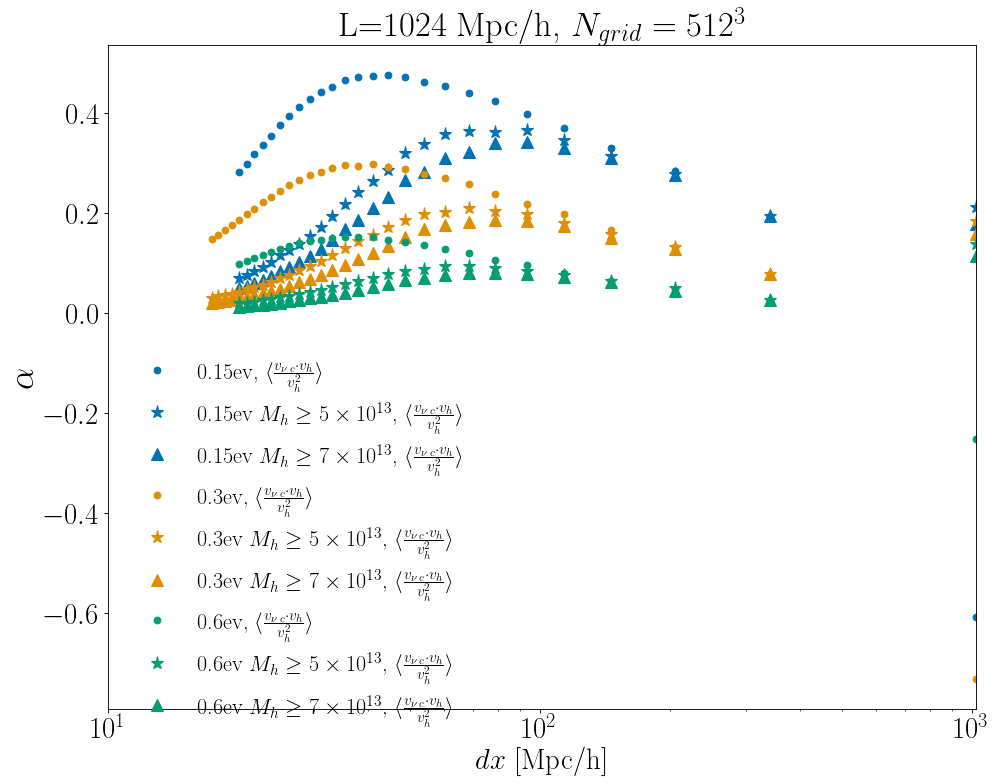

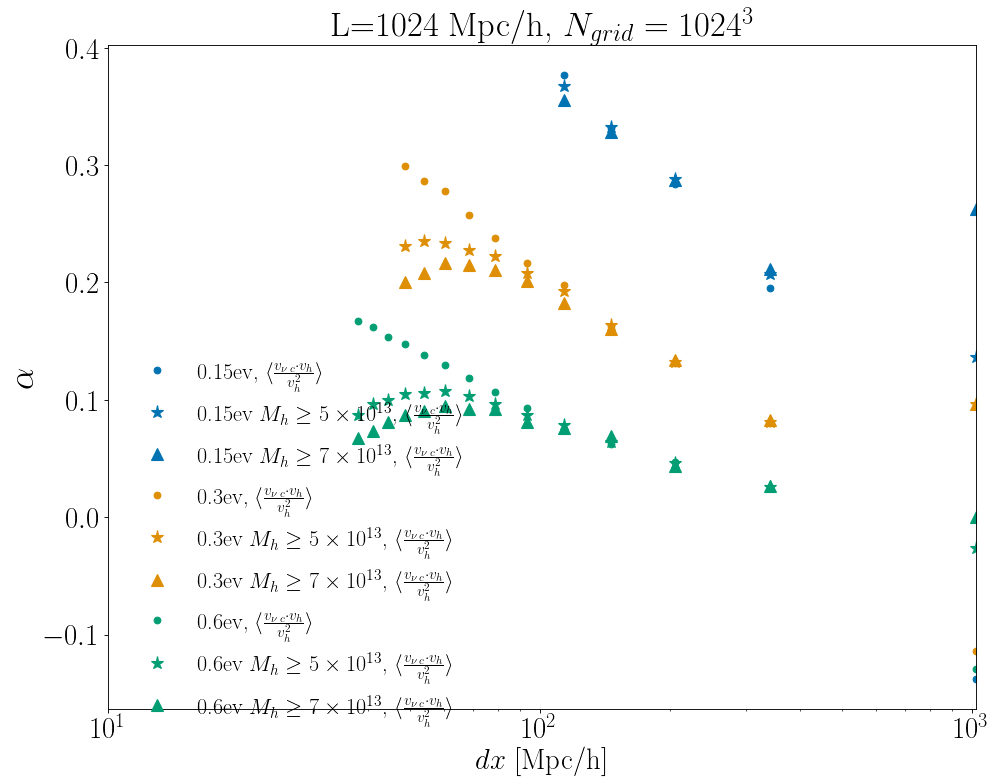

In [130]:
c = 26
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': c}
matplotlib.rc('font', **font)

for spec in specs:
    figure(figsize=(14, 11), dpi=80)
    if spec == "L_1024_Ngrid_512":
        title_name = r"L=1024 Mpc/h, $N_{grid}=512^3$"
    elif spec == "L_1024_Ngrid_1024":
        title_name = r"L=1024 Mpc/h, $N_{grid}=1024^3$"
    l=0
    for sim in sims:
        ###FIG###
        dx = data[sim][spec]['dx']
        d1 = data[sim][spec]['v_cnu.v_h/v_h^2']
        d2 = data[sim][spec]['v_cnu.v_h/v_h^2(M>5.e13)']
        d3 = data[sim][spec]['v_cnu.v_h/v_h^2(M>7.e13)']

        plt.plot(dx, d1 ,".", color=Colors[l], markersize=12, label =sim+r", $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")
        plt.plot(dx, d2 ,"*", color=Colors[l], markersize=12, label =sim+r" $M_h \ge 5 \times 10^{13}$, $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")
        plt.plot(dx, d3,"^", color=Colors[l], markersize=10, label =sim+r" $M_h \ge 7 \times 10^{13}$, $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")

        l=l+1
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro", label =r"$<v_{h}>$")

#             else:
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p) ,"bo")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro")

        plt.xlim(10,1024)
        plt.title(title_name)
        # plt.ylim(1,1.e5)
        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r'$\alpha$',fontsize=32)
        plt.xscale('log')
        plt.legend(fontsize=20,bbox_to_anchor=[0.22,0.25],loc="center",frameon=False)# plt.yscale('symlog')

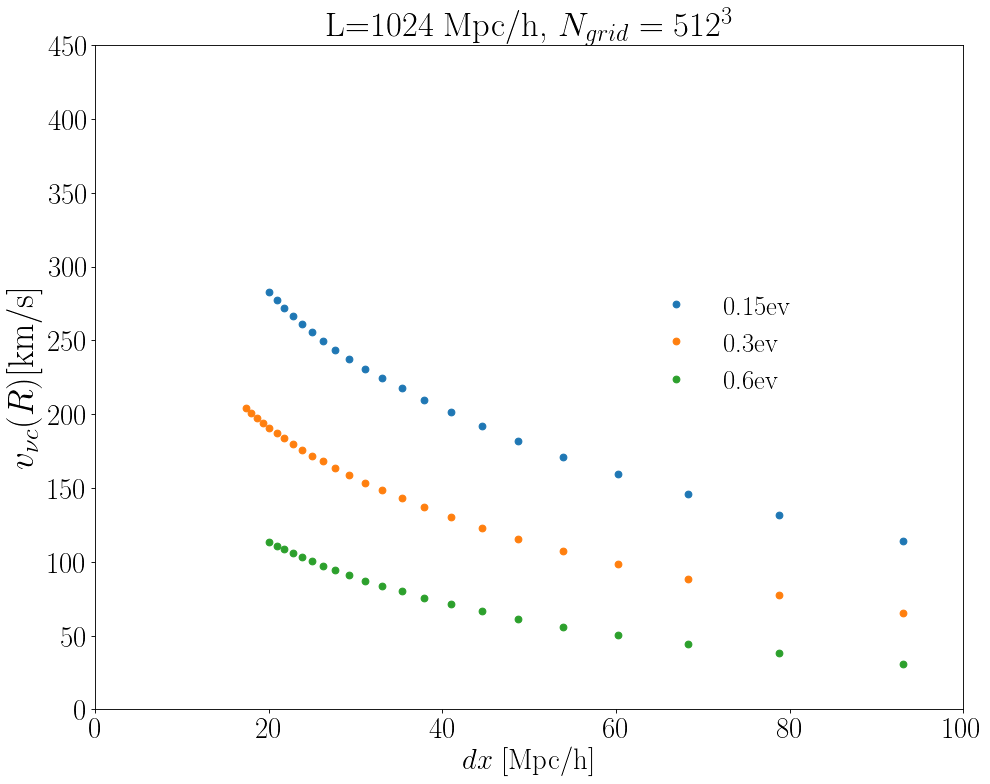

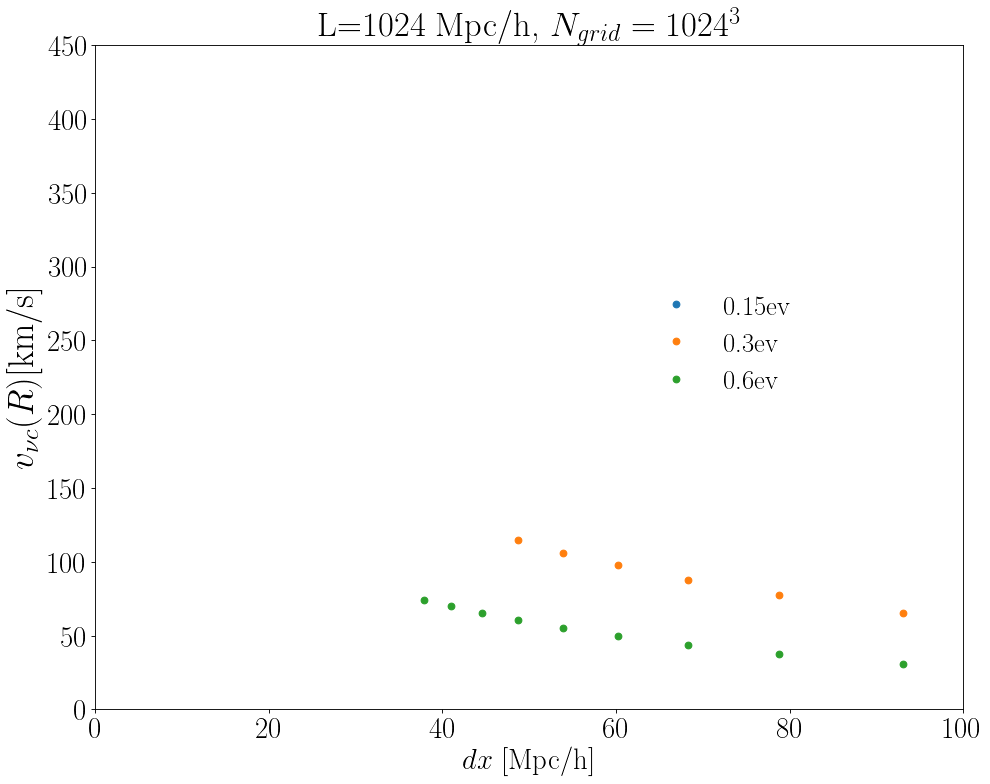

In [146]:
c = 26
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': c}
matplotlib.rc('font', **font)

for spec in specs:
    figure(figsize=(14, 11), dpi=80)
    if spec == "L_1024_Ngrid_512":
        title_name = r"L=1024 Mpc/h, $N_{grid}=512^3$"
    elif spec == "L_1024_Ngrid_1024":
        title_name = r"L=1024 Mpc/h, $N_{grid}=1024^3$"
    
    for sim in sims:
        ###FIG###
        dx = data[sim][spec]['dx']
        d1 = data[sim][spec]['v_cnu.v_cnu']
        # d2 = data[sim][spec]['v_cnu.v_h/v_h^2(M>5.e13)']
        # d3 = data[sim][spec]['v_cnu.v_h/v_h^2(M>7.e13)']

        plt.plot(dx, np.sqrt(d1) ,"o", label =sim)#+r", $\frac{\langle v_{\nu \, c} \cdot v_h  \rangle}{\langle v_h^2 \rangle}$")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro", label =r"$<v_{h}>$")

#             else:
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p) ,"bo")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro")

        plt.xlim(0,100)
        plt.title(title_name)
        plt.ylim(0,450)
        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r'$v_{\nu c}(R)$[km/s]',fontsize=32)
        # plt.xscale('log')
        plt.legend(fontsize=24,bbox_to_anchor=[0.72,0.55],loc="center",frameon=False)# plt.yscale('symlog')

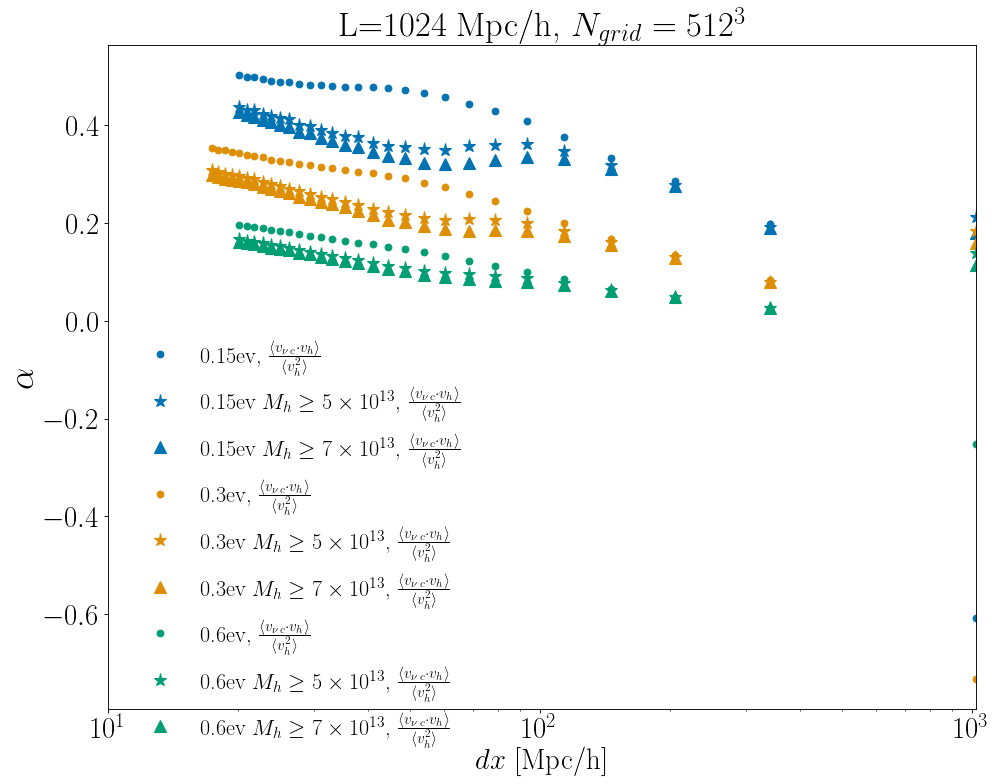

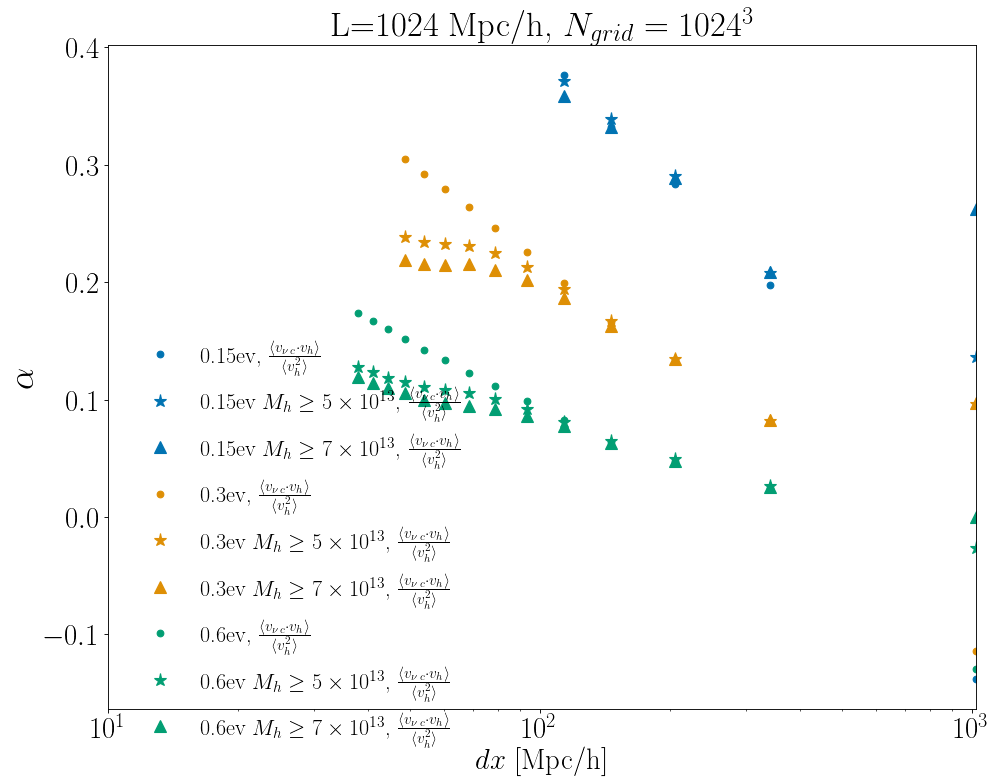

In [137]:
c = 26
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': c}
matplotlib.rc('font', **font)

for spec in specs:
    figure(figsize=(14, 11), dpi=80)
    if spec == "L_1024_Ngrid_512":
        title_name = r"L=1024 Mpc/h, $N_{grid}=512^3$"
    elif spec == "L_1024_Ngrid_1024":
        title_name = r"L=1024 Mpc/h, $N_{grid}=1024^3$"
    l=0
    for sim in sims:
        ###FIG###
        dx = data[sim][spec]['dx']
        d1 = data[sim][spec]['v_h.v_nuc']
        d2 = data[sim][spec]['v_h.v_nuc(M>5.e13)']
        d3 = data[sim][spec]['v_h.v_nuc(M>7.e13)']
        l1= data[sim][spec]['v_h.v_h']
        l2= data[sim][spec]['v_h.v_h(M>5.e13)']
        l3= data[sim][spec]['v_h.v_h(M>7.e13)']

        plt.plot(dx, d1/l1 ,".", color=Colors[l], markersize=12, label =sim+r", $ \frac{ \langle v_{\nu \, c} \cdot v_h  \rangle }{ \langle v_h^2 \rangle} $")
        plt.plot(dx, d2/l2 ,"*", color=Colors[l], markersize=12, label =sim+r" $M_h \ge 5 \times 10^{13}$, $\frac{ \langle v_{\nu \, c} \cdot v_h  \rangle }{ \langle v_h^2 \rangle} $")
        plt.plot(dx, d3/l3,"^", color=Colors[l], markersize=10, label =sim+r" $M_h \ge 7 \times 10^{13}$, $\frac{ \langle v_{\nu \, c} \cdot v_h  \rangle }{ \langle v_h^2 \rangle} $")

        l=l+1
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro", label =r"$<v_{h}>$")

#             else:
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p) ,"bo")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro")

        plt.xlim(10,1024)
        plt.title(title_name)
        # plt.ylim(1,1.e5)
        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r'$\alpha$',fontsize=32)
        plt.xscale('log')
        plt.legend(fontsize=20,bbox_to_anchor=[0.22,0.25],loc="center",frameon=False)# plt.yscale('symlog')

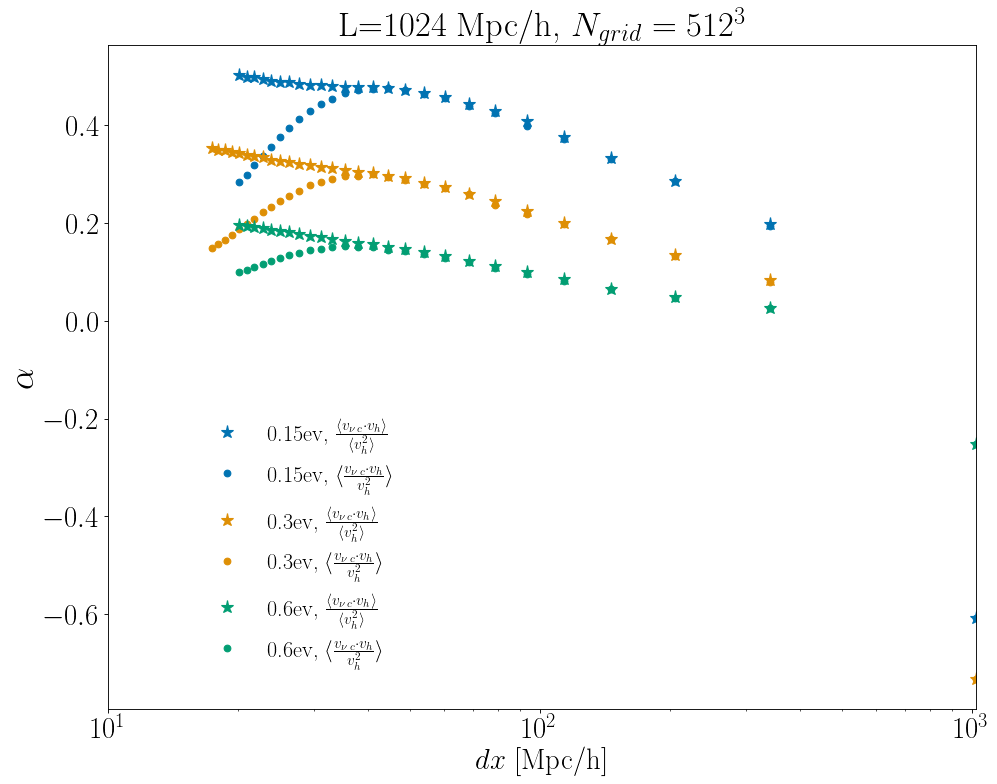

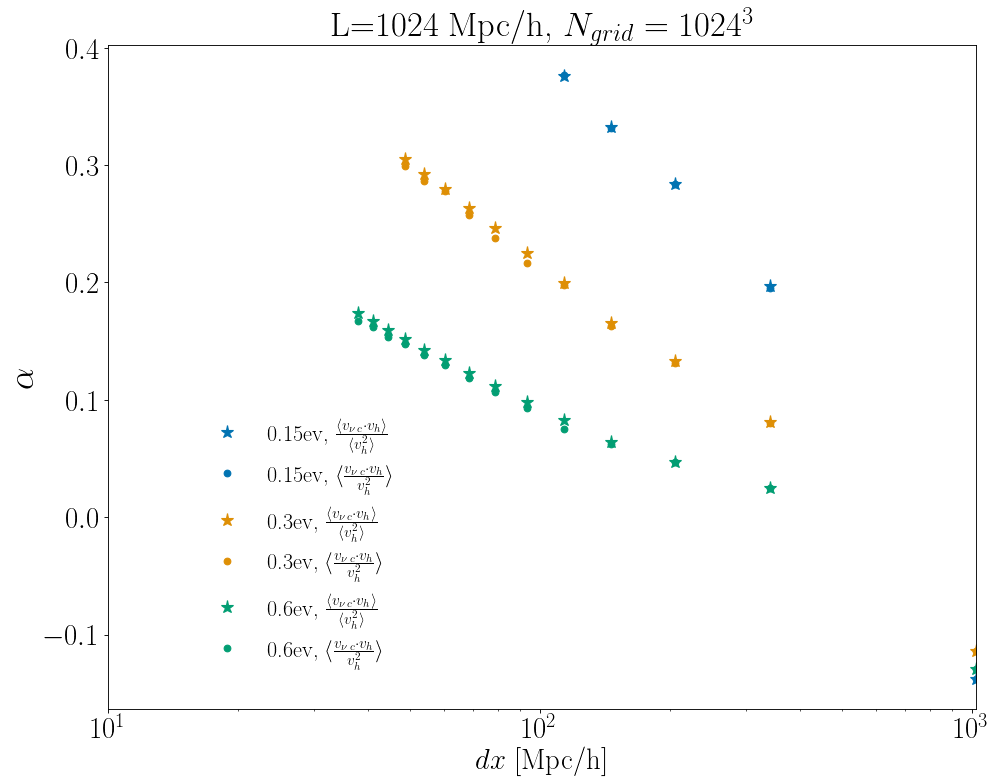

In [144]:
c = 26
plt.rc('text', usetex=True)
font = {'family': 'normal',
        'weight': 'bold',
        'size': c}
matplotlib.rc('font', **font)

for spec in specs:
    figure(figsize=(14, 11), dpi=80)
    if spec == "L_1024_Ngrid_512":
        title_name = r"L=1024 Mpc/h, $N_{grid}=512^3$"
    elif spec == "L_1024_Ngrid_1024":
        title_name = r"L=1024 Mpc/h, $N_{grid}=1024^3$"
    l=0
    for sim in sims:
        ###FIG###
        dx = data[sim][spec]['dx']
        d1 = data[sim][spec]['v_h.v_nuc']
        d2 = data[sim][spec]['v_h.v_nuc(M>5.e13)']
        d3 = data[sim][spec]['v_h.v_nuc(M>7.e13)']
        l1= data[sim][spec]['v_h.v_h']
        l2= data[sim][spec]['v_h.v_h(M>5.e13)']
        l3= data[sim][spec]['v_h.v_h(M>7.e13)']

        plt.plot(dx, d1/l1 ,"*", color=Colors[l], markersize=12, label =sim+r", $ \frac{ \langle v_{\nu \, c} \cdot v_h  \rangle }{ \langle v_h^2 \rangle} $")
        # plt.plot(dx, d2/l2 ,"o", color=Colors[l+5], markersize=12, label =sim+r" $M_h \ge 5 \times 10^{13}$, $\frac{ \langle v_{\nu \, c} \cdot v_h  \rangle }{ \langle v_h^2 \rangle} $")
        # plt.plot(dx, d3/l3,"^", color=Colors[l], markersize=10, label =sim+r" $M_h \ge 7 \times 10^{13}$, $\frac{ \langle v_{\nu \, c} \cdot v_h  \rangle }{ \langle v_h^2 \rangle} $")

        dx = data[sim][spec]['dx']
        d1 = data[sim][spec]['v_cnu.v_h/v_h^2']
        d2 = data[sim][spec]['v_cnu.v_h/v_h^2(M>5.e13)']
        d3 = data[sim][spec]['v_cnu.v_h/v_h^2(M>7.e13)']

        plt.plot(dx, d1 ,".", color=Colors[l], markersize=12, label =sim+r", $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")
        # plt.plot(dx, d2 ,"s", color=Colors[l+5], markersize=12, label =sim+r" $M_h \ge 5 \times 10^{13}$, $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")
        # plt.plot(dx, d3,"^", color=Colors[l], markersize=10, label =sim+r" $M_h \ge 7 \times 10^{13}$, $\langle \frac{v_{\nu \, c} \cdot v_h}{v_h^2} \rangle$")

        l=l+1
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro", label =r"$<v_{h}>$")

#             else:
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p) ,"bo")
#                 plt.plot(data['dx'][ngrid],  np.sqrt(p2)/10 ,"ro")

        plt.xlim(10,1024)
        plt.title(title_name)
        # plt.ylim(1,1.e5)
        plt.xlabel(r"$dx$ [Mpc/h]")
        plt.ylabel(r'$\alpha$',fontsize=32)
        plt.xscale('log')
        plt.legend(fontsize=20,bbox_to_anchor=[0.22,0.25],loc="center",frameon=False)# plt.yscale('symlog')